# Rust vs Python Engine Benchmark (Local + Colab)

This notebook benchmarks ROOKHIDE engines with a **fast strategy**:
- Rust: measured for all sizes (50KB to 5MB)
- Python: measured up to 500KB, then projected for 1MB/2MB/5MB

It is configured to run locally first, and still works in Colab.

In [11]:
# Install Python dependencies (local/colab friendly)
!python -m pip -q install --upgrade pip
!python -m pip -q install maturin matplotlib python-chess cryptography

In [12]:
# Resolve repository path for local or Colab
import os
from pathlib import Path

# Local-first: walk upward from cwd to find repo root (encode.py + rust_engine/)
cwd = Path.cwd().resolve()
REPO_DIR = None
for candidate in [cwd, *cwd.parents]:
    if (candidate / "encode.py").exists() and (candidate / "rust_engine").exists():
        REPO_DIR = str(candidate)
        break

if REPO_DIR is None:
    REPO_URL = "https://github.com/PERIL03/PAWN_STARS.git"
    REPO_DIR = "/content/PAWN_STARS"
    if not os.path.exists(REPO_DIR):
        !git clone $REPO_URL $REPO_DIR

%cd $REPO_DIR
print("Using repo:", REPO_DIR)

/Users/rishuraj/Desktop/RUST
Using repo: /Users/rishuraj/Desktop/RUST


In [13]:
# Build and install Rust engine wheel
!python -m pip -q install maturin
!cd rust_engine && maturin build --release -i python3
!python -m pip -q install rust_engine/target/wheels/*.whl

🔗 Found pyo3 bindings
🐍 Found CPython 3.13 at /Users/rishuraj/Desktop/RUST/.venv/bin/python3
📡 Using build options features from pyproject.toml
💻 Using `MACOSX_DEPLOYMENT_TARGET=11.0` for aarch64-apple-darwin by default
   Compiling pyo3-build-config v0.22.6
   Compiling pyo3-ffi v0.22.6=======>    ] 79/91: pyo3-build-config           
   Compiling pyo3-macros-backend v0.22.6
   Compiling pyo3 v0.22.6
   Compiling pyo3-macros v0.22.6======>  ] 87/91: pyo3-macros-backend         
   Compiling chess_engine v0.1.0 (/Users/rishuraj/Desktop/RUST/rust_engine)   
    Finished `release` profile [optimized] target(s) in 12.63s                
📦 Built wheel for CPython 3.13 to /Users/rishuraj/Desktop/RUST/rust_engine/target/wheels/chess_engine-0.1.0-cp313-cp313-macosx_11_0_arm64.whl


In [14]:
import os
import sys
import json
import tempfile
from pathlib import Path
from time import perf_counter
from statistics import mean

import matplotlib.pyplot as plt

# Ensure repository root is importable even if notebook runs from scripts/
repo_root = Path(REPO_DIR).resolve() if 'REPO_DIR' in globals() else Path.cwd().resolve()
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

import encode as encode_mod
import decode as decode_mod

RUST_AVAILABLE = encode_mod.RUST_ENGINE_AVAILABLE and decode_mod.RUST_ENGINE_AVAILABLE
print("Rust available:", RUST_AVAILABLE)

Rust available: True


In [15]:
# Benchmark helpers
SIZES = [50*1024, 100*1024, 250*1024, 500*1024, 1024*1024, 2*1024*1024, 5*1024*1024]
PYTHON_MEASURED_SIZES = [50*1024, 100*1024, 250*1024, 500*1024]
REPEATS_RUST = 1
REPEATS_PY = 1

def run_once(mode: str, payload: bytes):
    with tempfile.TemporaryDirectory() as td:
        inp = Path(td) / "input.bin"
        pgn = Path(td) / "encoded.pgn"
        out = Path(td) / "decoded.bin"

        inp.write_bytes(payload)

        if mode == "python":
            encode_mod.RUST_ENGINE_AVAILABLE = False
            decode_mod.RUST_ENGINE_AVAILABLE = False
        else:
            encode_mod.RUST_ENGINE_AVAILABLE = RUST_AVAILABLE
            decode_mod.RUST_ENGINE_AVAILABLE = RUST_AVAILABLE

        t0 = perf_counter()
        meta = encode_mod.encode(str(inp), str(pgn))
        t1 = perf_counter()
        decode_mod.decode(str(pgn), str(out))
        t2 = perf_counter()

        ok = out.read_bytes() == payload
        return {
            "encode_s": t1 - t0,
            "decode_s": t2 - t1,
            "total_s": t2 - t0,
            "throughput_kbs": (len(payload) / 1024) / (t2 - t0),
            "expansion": float(meta.get("expansion_ratio", 0.0)),
            "ok": ok,
        }

def run_avg(mode: str, size: int, repeats: int):
    payload = os.urandom(size)
    samples = [run_once(mode, payload) for _ in range(repeats)]
    return {
        "mode": mode,
        "size_bytes": size,
        "encode_s": mean(s["encode_s"] for s in samples),
        "decode_s": mean(s["decode_s"] for s in samples),
        "total_s": mean(s["total_s"] for s in samples),
        "throughput_kbs": mean(s["throughput_kbs"] for s in samples),
        "expansion": mean(s["expansion"] for s in samples),
        "ok": all(s["ok"] for s in samples),
        "estimated": False,
    }

In [16]:
# Run benchmarks
results = []

print("Running Rust benchmarks...")
for s in SIZES:
    r = run_avg("rust", s, REPEATS_RUST)
    results.append(r)
    print(f"RUST {s//1024:>5} KB -> total={r['total_s']:.3f}s, thr={r['throughput_kbs']:.2f} KB/s")

print("\nRunning Python benchmarks (measured subset)...")
for s in PYTHON_MEASURED_SIZES:
    r = run_avg("python", s, REPEATS_PY)
    results.append(r)
    print(f"PY    {s//1024:>5} KB -> total={r['total_s']:.3f}s, thr={r['throughput_kbs']:.2f} KB/s")

py_measured = [r for r in results if r['mode'] == 'python' and not r['estimated']]
avg_py_thr = mean(r['throughput_kbs'] for r in py_measured)

for s in [1024*1024, 2*1024*1024, 5*1024*1024]:
    if s not in [r['size_bytes'] for r in py_measured]:
        total_est = (s / 1024) / avg_py_thr
        results.append({
            'mode': 'python',
            'size_bytes': s,
            'encode_s': None,
            'decode_s': None,
            'total_s': total_est,
            'throughput_kbs': avg_py_thr,
            'expansion': None,
            'ok': True,
            'estimated': True,
        })

print("\nPython avg measured throughput used for projection:", round(avg_py_thr, 3), "KB/s")

Running Rust benchmarks...


DEBUG:encode:Skipping compression: no meaningful size reduction
DEBUG:encode:[RUST] Starting encoding
[rust v3] Encode+PGN 51221 bytes in 0.048s — 105675 moves, 379 games — 2210620 m/s
DEBUG:encode:[RUST] Encoding completed in 0.06s
[rust] Decode+PGN-parse 51221 bytes in 0.035s — 105675 moves — 3008766 m/s (v3)
DEBUG:decode:[RUST] Successfully decoded 51200 bytes
DEBUG:encode:Skipping compression: no meaningful size reduction
DEBUG:encode:[RUST] Starting encoding
[rust v3] Encode+PGN 102421 bytes in 0.096s — 210310 moves, 765 games — 2195370 m/s
DEBUG:encode:[RUST] Encoding completed in 0.11s


RUST    50 KB -> total=0.211s, thr=237.36 KB/s


[rust] Decode+PGN-parse 102421 bytes in 0.074s — 210310 moves — 2855346 m/s (v3)
DEBUG:decode:[RUST] Successfully decoded 102400 bytes
DEBUG:encode:Skipping compression: no meaningful size reduction
DEBUG:encode:[RUST] Starting encoding
[rust v3] Encode+PGN 256021 bytes in 0.218s — 527110 moves, 1900 games — 2416142 m/s


RUST   100 KB -> total=0.253s, thr=394.66 KB/s


...

PY      100 KB -> total=52.178s, thr=1.92 KB/s


DEBUG:encode:Encoding completed successfully in 103.21 seconds
DEBUG:encode:Created 1934 game(s)
DEBUG:decode:Successfully decoded 256000 bytes
DEBUG:encode:Skipping compression: no meaningful size reduction
DEBUG:encode:Starting pure-Python encoding path


PY      250 KB -> total=130.207s, thr=1.92 KB/s


DEBUG:encode:Encoding completed successfully in 203.37 seconds
DEBUG:encode:Created 3883 game(s)
DEBUG:decode:Successfully decoded 512000 bytes


PY      500 KB -> total=257.266s, thr=1.94 KB/s

Python avg measured throughput used for projection: 1.921 KB/s


In [17]:
# Build comparison table
sizes_sorted = sorted(set(r['size_bytes'] for r in results))
rust_rows = {r['size_bytes']: r for r in results if r['mode'] == 'rust'}
py_rows = {r['size_bytes']: r for r in results if r['mode'] == 'python'}

table = []
for s in sizes_sorted:
    rr = rust_rows[s]
    pr = py_rows[s]
    table.append({
        'size_kb': s // 1024,
        'rust_total_s': rr['total_s'],
        'python_total_s': pr['total_s'],
        'speedup_x': pr['total_s'] / rr['total_s'],
        'rust_thr_kbs': rr['throughput_kbs'],
        'python_thr_kbs': pr['throughput_kbs'],
        'python_estimated': pr['estimated'],
    })

for row in table:
    est = " (est)" if row['python_estimated'] else ""
    print(
        f"{row['size_kb']:>5} KB | Rust {row['rust_total_s']:.3f}s | "
        f"Python {row['python_total_s']:.3f}s{est} | Speedup {row['speedup_x']:.2f}x"
    )

   50 KB | Rust 0.211s | Python 26.256s | Speedup 124.64x
  100 KB | Rust 0.253s | Python 52.178s | Speedup 205.93x
  250 KB | Rust 0.569s | Python 130.207s | Speedup 228.73x
  500 KB | Rust 1.064s | Python 257.266s | Speedup 241.88x
 1024 KB | Rust 2.120s | Python 533.030s (est) | Speedup 251.46x
 2048 KB | Rust 4.545s | Python 1066.060s (est) | Speedup 234.54x
 5120 KB | Rust 11.202s | Python 2665.151s (est) | Speedup 237.92x


DEBUG:matplotlib.pyplot:Loaded backend module://matplotlib_inline.backend_inline version unknown.
DEBUG:matplotlib.pyplot:Loaded backend module://matplotlib_inline.backend_inline version unknown.
DEBUG:matplotlib.font_manager:findfont: Matching sans\-serif:style=normal:variant=normal:weight=normal:stretch=normal:size=10.0.
DEBUG:matplotlib.font_manager:findfont: score(FontEntry(fname='/Users/rishuraj/Desktop/RUST/.venv/lib/python3.13/site-packages/matplotlib/mpl-data/fonts/ttf/cmmi10.ttf', name='cmmi10', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 10.05
DEBUG:matplotlib.font_manager:findfont: score(FontEntry(fname='/Users/rishuraj/Desktop/RUST/.venv/lib/python3.13/site-packages/matplotlib/mpl-data/fonts/ttf/STIXGeneralItalic.ttf', name='STIXGeneral', style='italic', variant='normal', weight=400, stretch='normal', size='scalable')) = 11.05
DEBUG:matplotlib.font_manager:findfont: score(FontEntry(fname='/Users/rishuraj/Desktop/RUST/.venv/lib/python3

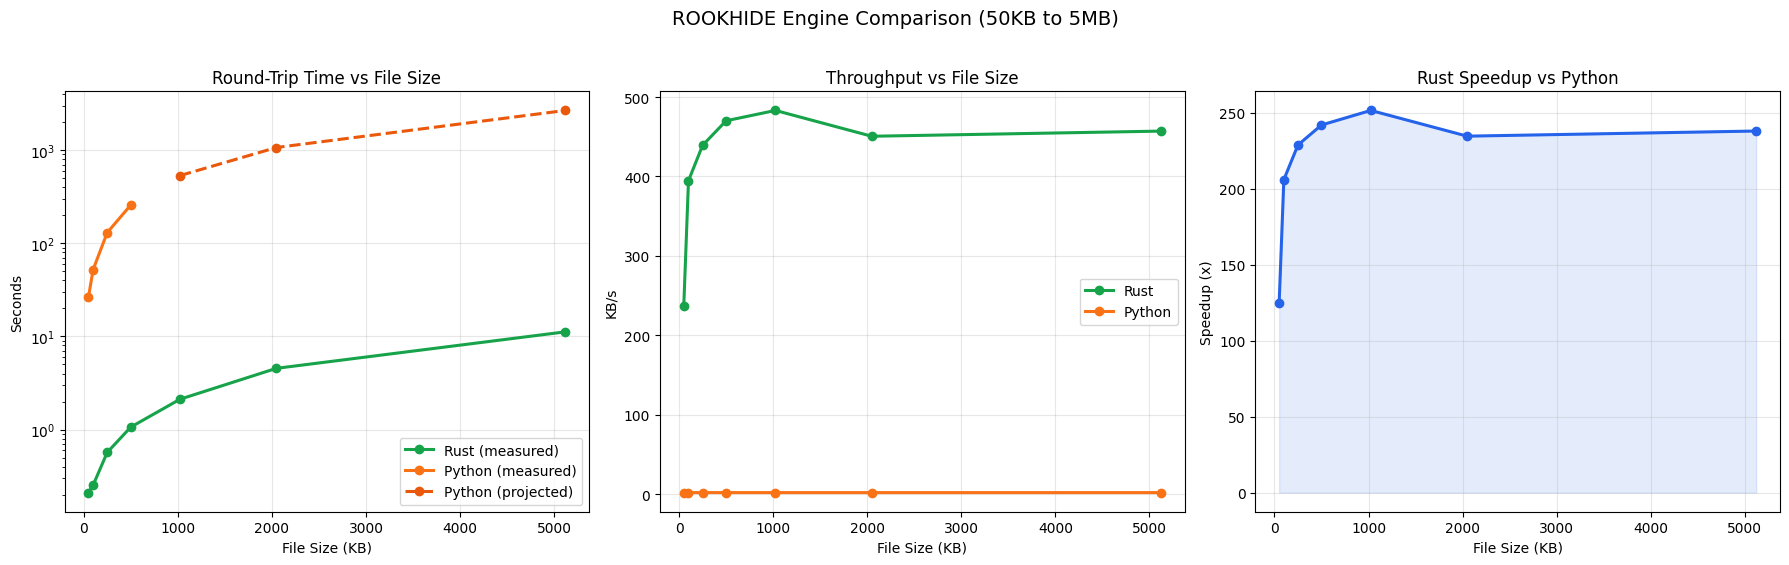

In [18]:
# Proper presentation graphs
x_kb = [r['size_kb'] for r in table]
rust_total = [r['rust_total_s'] for r in table]
py_total_measured = [r['python_total_s'] if not r['python_estimated'] else None for r in table]
py_total_est = [r['python_total_s'] if r['python_estimated'] else None for r in table]
rust_thr = [r['rust_thr_kbs'] for r in table]
py_thr = [r['python_thr_kbs'] for r in table]
speedup = [r['speedup_x'] for r in table]

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

# 1) Total time
axes[0].plot(x_kb, rust_total, marker='o', linewidth=2.2, label='Rust (measured)', color='#16a34a')
axes[0].plot(x_kb, py_total_measured, marker='o', linewidth=2.2, label='Python (measured)', color='#f97316')
axes[0].plot(x_kb, py_total_est, marker='o', linewidth=2.2, linestyle='--', label='Python (projected)', color='#ea580c')
axes[0].set_title('Round-Trip Time vs File Size')
axes[0].set_xlabel('File Size (KB)')
axes[0].set_ylabel('Seconds')
axes[0].set_yscale('log')
axes[0].grid(alpha=0.3)
axes[0].legend()

# 2) Throughput
axes[1].plot(x_kb, rust_thr, marker='o', linewidth=2.2, label='Rust', color='#16a34a')
axes[1].plot(x_kb, py_thr, marker='o', linewidth=2.2, label='Python', color='#f97316')
axes[1].set_title('Throughput vs File Size')
axes[1].set_xlabel('File Size (KB)')
axes[1].set_ylabel('KB/s')
axes[1].grid(alpha=0.3)
axes[1].legend()

# 3) Speedup
axes[2].plot(x_kb, speedup, marker='o', linewidth=2.2, color='#2563eb')
axes[2].fill_between(x_kb, speedup, alpha=0.12, color='#2563eb')
axes[2].set_title('Rust Speedup vs Python')
axes[2].set_xlabel('File Size (KB)')
axes[2].set_ylabel('Speedup (x)')
axes[2].grid(alpha=0.3)

fig.suptitle('ROOKHIDE Engine Comparison (50KB to 5MB)', fontsize=14, y=1.02)
fig.tight_layout()
plt.show()

DEBUG:matplotlib.ticker:vmin 0.1313556762523764 vmax 4273.956263526038
DEBUG:matplotlib.ticker:ticklocs array([1.e-02, 1.e-01, 1.e+00, 1.e+01, 1.e+02, 1.e+03, 1.e+04, 1.e+05])
DEBUG:matplotlib.ticker:vmin 0.1313556762523764 vmax 4273.956263526038
DEBUG:matplotlib.ticker:ticklocs array([2.e-02, 3.e-02, 4.e-02, 5.e-02, 6.e-02, 7.e-02, 8.e-02, 9.e-02,
       2.e-01, 3.e-01, 4.e-01, 5.e-01, 6.e-01, 7.e-01, 8.e-01, 9.e-01,
       2.e+00, 3.e+00, 4.e+00, 5.e+00, 6.e+00, 7.e+00, 8.e+00, 9.e+00,
       2.e+01, 3.e+01, 4.e+01, 5.e+01, 6.e+01, 7.e+01, 8.e+01, 9.e+01,
       2.e+02, 3.e+02, 4.e+02, 5.e+02, 6.e+02, 7.e+02, 8.e+02, 9.e+02,
       2.e+03, 3.e+03, 4.e+03, 5.e+03, 6.e+03, 7.e+03, 8.e+03, 9.e+03,
       2.e+04, 3.e+04, 4.e+04, 5.e+04, 6.e+04, 7.e+04, 8.e+04, 9.e+04,
       2.e+05, 3.e+05, 4.e+05, 5.e+05, 6.e+05, 7.e+05, 8.e+05, 9.e+05])
DEBUG:matplotlib.ticker:vmin 0.1313556762523764 vmax 4273.956263526038
DEBUG:matplotlib.ticker:ticklocs array([1.e-02, 1.e-01, 1.e+00, 1.e+01, 1.e+02, 

Saved:
- /Users/rishuraj/Desktop/RUST/outputs/benchmarks/engine_comparison_50KB_to_5MB.json
- /Users/rishuraj/Desktop/RUST/outputs/benchmarks/engine_comparison_50KB_to_5MB.png
- /Users/rishuraj/Desktop/RUST/outputs/benchmarks/engine_comparison_50KB_to_5MB_summary.txt


DEBUG:matplotlib.ticker:vmin 0.1313556762523764 vmax 4273.956263526038
DEBUG:matplotlib.ticker:ticklocs array([1.e-02, 1.e-01, 1.e+00, 1.e+01, 1.e+02, 1.e+03, 1.e+04, 1.e+05])
DEBUG:matplotlib.ticker:vmin 0.1313556762523764 vmax 4273.956263526038
DEBUG:matplotlib.ticker:ticklocs array([2.e-02, 3.e-02, 4.e-02, 5.e-02, 6.e-02, 7.e-02, 8.e-02, 9.e-02,
       2.e-01, 3.e-01, 4.e-01, 5.e-01, 6.e-01, 7.e-01, 8.e-01, 9.e-01,
       2.e+00, 3.e+00, 4.e+00, 5.e+00, 6.e+00, 7.e+00, 8.e+00, 9.e+00,
       2.e+01, 3.e+01, 4.e+01, 5.e+01, 6.e+01, 7.e+01, 8.e+01, 9.e+01,
       2.e+02, 3.e+02, 4.e+02, 5.e+02, 6.e+02, 7.e+02, 8.e+02, 9.e+02,
       2.e+03, 3.e+03, 4.e+03, 5.e+03, 6.e+03, 7.e+03, 8.e+03, 9.e+03,
       2.e+04, 3.e+04, 4.e+04, 5.e+04, 6.e+04, 7.e+04, 8.e+04, 9.e+04,
       2.e+05, 3.e+05, 4.e+05, 5.e+05, 6.e+05, 7.e+05, 8.e+05, 9.e+05])
DEBUG:matplotlib.ticker:vmin 0.1313556762523764 vmax 4273.956263526038
DEBUG:matplotlib.ticker:ticklocs array([1.e-02, 1.e-01, 1.e+00, 1.e+01, 1.e+02, 

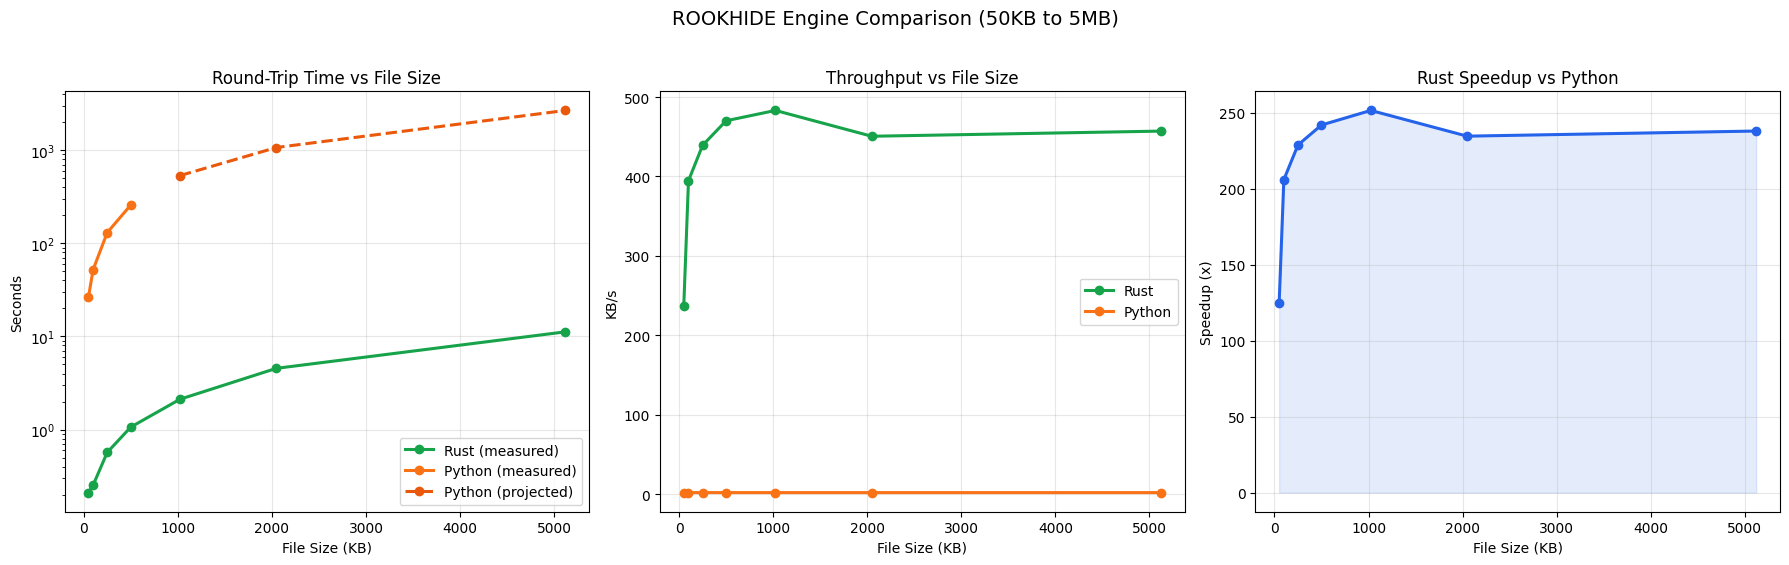

In [19]:
# Save artifacts
out_dir = Path('outputs/benchmarks')
out_dir.mkdir(parents=True, exist_ok=True)

json_path = out_dir / 'engine_comparison_50KB_to_5MB.json'
png_path = out_dir / 'engine_comparison_50KB_to_5MB.png'
summary_path = out_dir / 'engine_comparison_50KB_to_5MB_summary.txt'

json_path.write_text(json.dumps({'table': table, 'raw_results': results}, indent=2), encoding='utf-8')
plt.figure(figsize=(1,1))
plt.close('all')

# Recreate and save the figure
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
axes[0].plot(x_kb, rust_total, marker='o', linewidth=2.2, label='Rust (measured)', color='#16a34a')
axes[0].plot(x_kb, py_total_measured, marker='o', linewidth=2.2, label='Python (measured)', color='#f97316')
axes[0].plot(x_kb, py_total_est, marker='o', linewidth=2.2, linestyle='--', label='Python (projected)', color='#ea580c')
axes[0].set_yscale('log')
axes[0].set_title('Round-Trip Time vs File Size')
axes[0].set_xlabel('File Size (KB)')
axes[0].set_ylabel('Seconds')
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].plot(x_kb, rust_thr, marker='o', linewidth=2.2, label='Rust', color='#16a34a')
axes[1].plot(x_kb, py_thr, marker='o', linewidth=2.2, label='Python', color='#f97316')
axes[1].set_title('Throughput vs File Size')
axes[1].set_xlabel('File Size (KB)')
axes[1].set_ylabel('KB/s')
axes[1].grid(alpha=0.3)
axes[1].legend()

axes[2].plot(x_kb, speedup, marker='o', linewidth=2.2, color='#2563eb')
axes[2].fill_between(x_kb, speedup, alpha=0.12, color='#2563eb')
axes[2].set_title('Rust Speedup vs Python')
axes[2].set_xlabel('File Size (KB)')
axes[2].set_ylabel('Speedup (x)')
axes[2].grid(alpha=0.3)

fig.suptitle('ROOKHIDE Engine Comparison (50KB to 5MB)', fontsize=14, y=1.02)
fig.tight_layout()
fig.savefig(png_path, dpi=180, bbox_inches='tight')

avg_speedup = sum(speedup) / len(speedup)
summary = [
    'ROOKHIDE Engine Comparison (50KB to 5MB)',
    '',
    f'Average Rust speedup: {avg_speedup:.2f}x',
    '',
    'Size(KB) | Rust(s) | Python(s) | Speedup(x) | Python source',
]
for r in table:
    source = 'projected' if r['python_estimated'] else 'measured'
    summary.append(f"{r['size_kb']:>7} | {r['rust_total_s']:.3f} | {r['python_total_s']:.3f} | {r['speedup_x']:.2f} | {source}")
summary_path.write_text('\n'.join(summary), encoding='utf-8')

print('Saved:')
print('-', json_path.resolve())
print('-', png_path.resolve())
print('-', summary_path.resolve())